In [ ]:
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 30.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
import pywt
from scipy.stats import moment, skew, mode
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# Function for DWT decomposition
def dwt_decomposition(signal, wavelet='db4', level=8):
    """Performs DWT on a signal and returns the level-8 detail and approximation coefficients."""
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    cd8 = coeffs[-1]
    ca8 = coeffs[0]
    return cd8, ca8


# Function for extracting statistical features
def extract_statistical_features(signal, name, p):
    """Extracts statistical features from a given 1D signal."""
    features = {}
    features[name + '_' + p + '_std'] = np.std(signal)
    features[name + '_' + p + '_var'] = np.var(signal)
    features[name + '_' + p + '_mom3'] = moment(signal, moment=3)
    features[name + '_' + p + '_skn'] = skew(signal)
    mode_value, _ = mode(signal, axis=None)
    features[name + '_' + p + '_mode'] = mode_value[0] if isinstance(mode_value, np.ndarray) and len(mode_value) > 0 else mode_value.item()
    return features


# Defining the base dataset directory
dataset_directory = '/content/drive/MyDrive/Dataset4'

final_data = []

fields = ['Va_G', 'Vb_G', 'Vc_G', 'V0', 'V1', 'V2']

for fault_type_folder in os.listdir(dataset_directory):
    fault_type_path = os.path.join(dataset_directory, fault_type_folder)

    if os.path.isdir(fault_type_path):
        for subfolder in os.listdir(fault_type_path):
            subfolder_path = os.path.join(fault_type_path, subfolder)

            if os.path.isdir(subfolder_path):
                for json_file in os.listdir(subfolder_path):
                    if json_file.endswith('.json'):
                        file_path = os.path.join(subfolder_path, json_file)
                        with open(file_path, 'r') as file:
                            # Load JSON content
                            res = json.load(file)
                            # print(file_path)
                            extracted_features = {}
                            for name in fields:
                                if name in res:
                                    decomposed = dwt_decomposition(res[name])
                                    feat1 = extract_statistical_features(decomposed[0], name, 'D')
                                    feat2 = extract_statistical_features(decomposed[1], name, 'A')
                                    extracted_features.update(feat1)
                                    extracted_features.update(feat2)
                                    extracted_features.update(extract_statistical_features(res[name], name, name[1]))
                            # print(extracted_features)

                            extracted_features['fault_type'] = fault_type_folder
                            extracted_features['distance'] = float(subfolder)/10
                            # print(f"Number of extracted features: {len(extracted_features)}")
                            final_data.append(extracted_features)




In [ ]:

df = pd.DataFrame(final_data)


# df.to_csv('/content/extracted_features.csv', index=False)

# print(df)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# std_columns = [col for col in df.columns if '_std' in col]
X = df.drop(columns=['distance','fault_type'])

y = df['fault_type']


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

model.save('fault_detection_ann_model.h5')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6496 - loss: 1.0221 - val_accuracy: 0.9120 - val_loss: 0.1312
Epoch 2/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9088 - loss: 0.1578 - val_accuracy: 0.9092 - val_loss: 0.1269
Epoch 3/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9062 - loss: 0.1388 - val_accuracy: 0.9106 - val_loss: 0.1260
Epoch 4/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9104 - loss: 0.1324 - val_accuracy: 0.9092 - val_loss: 0.1273
Epoch 5/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9094 - loss: 0.1364 - val_accuracy: 0.9101 - val_loss: 0.1271
Epoch 6/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9156 - loss: 0.1252 - val_accuracy: 0.9106 - val_loss: 0.1256
Epoch 7/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9143 - loss: 0.1258 - val_accuracy: 0.9208 - val_loss: 0.1253
Epoch 8/50
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9168 - loss: 0.1235 - val_accuracy: 0.

Test Accuracy: 91.06%


In [ ]:
print(X_train.shape)

(8631, 90)


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


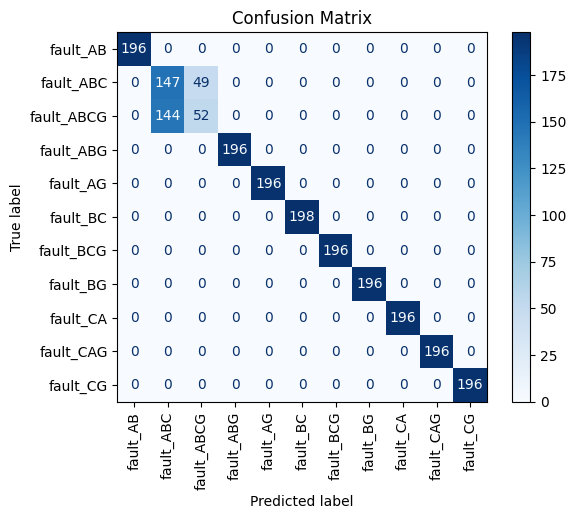

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# std_columns = [col for col in df.columns if ('_std' or '_skn') in col]  # Select columns with 'std'
X = df.drop(columns=['distance','fault_type'])  # Features
y = df['distance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train_scaled, y_train, epochs=200, batch_size=32, validation_data=(X_test_scaled, y_test))

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

model.save('fault_distance_ann_model_distance.h5')


Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.3558 - mae: 1.1785 - val_loss: 0.2317 - val_mae: 0.3827
Epoch 2/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5152 - mae: 0.5569 - val_loss: 0.1021 - val_mae: 0.2557
Epoch 3/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3634 - mae: 0.4650 - val_loss: 0.1002 - val_mae: 0.2556
Epoch 4/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3081 - mae: 0.4260 - val_loss: 0.0611 - val_mae: 0.1938
Epoch 5/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2663 - mae: 0.3958 - val_loss: 0.0901 - val_mae: 0.2482
Epoch 6/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2234 - mae: 0.3581 - val_loss: 0.0576 - val_mae: 0.1926
Epoch 7/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1953 - mae: 0.3384 - val_loss: 0.0479 - val_mae: 0.1750
Epoch 8/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1826 - mae: 0.3300 - val_loss: 0.0380 - val_mae: 0.1539
Epoch 9/200
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss:

Mean Squared Error (MSE): 0.01
Mean Absolute Error (MAE): 0.09
R² Score: 0.99


In [ ]:
random_index = np.random.randint(0, X_test_scaled.shape[0])

sample_input = X_test_scaled[random_index].reshape(1, -1)
actual_output = y_test.iloc[random_index]

predicted_output = model.predict(sample_input)[0][0]

print(f"Random Index: {random_index}")
print(f"Actual Fault Distance: {actual_output:.2f}")
print(f"Predicted Fault Distance: {predicted_output:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Random Index: 185
Actual Fault Distance: 2.90
Predicted Fault Distance: 2.83


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

fault_types = df['fault_type'].unique()

models = {}
results = {}

for fault_type in fault_types:
    print(f"Processing fault type: {fault_type}")

    fault_df = df[df['fault_type'] == fault_type]

    X = fault_df.drop(columns=['fault_type', 'distance'])
    y = fault_df['distance']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    history = model.fit(X_train_scaled, y_train, epochs=150, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=0)

    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    models[fault_type] = model
    results[fault_type] = {
        'mse': mse,
        'mae': mae,
        'r2': r2
    }

    print(f"Fault Type: {fault_type}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  R² Score: {r2:.2f}")
    print("-" * 30)

for fault_type, model in models.items():
    model.save(f"{fault_type}_ann_modelxyz.h5")


Processing fault type: fault_ABCG


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Fault Type: fault_ABCG
  Mean Squared Error (MSE): 0.02
  Mean Absolute Error (MAE): 0.11
  R² Score: 0.99
------------------------------
Processing fault type: fault_ABC


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


...

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Fault Type: fault_BG
  Mean Squared Error (MSE): 0.04
  Mean Absolute Error (MAE): 0.15
  R² Score: 0.98
------------------------------
Processing fault type: fault_CG


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


Fault Type: fault_CG
  Mean Squared Error (MSE): 0.01
  Mean Absolute Error (MAE): 0.08
  R² Score: 0.99
------------------------------


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Function to test the model and compare with real values
def test_distance_model(model, X_test_scaled, y_test):
    # Predicting the fault distances
    y_pred = model.predict(X_test_scaled).flatten()

    # Calculating the metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("Model Testing Results:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R² Score: {r2:.2f}")
    print("-" * 30)

    # Comparing real vs predicted values for the first 10 samples
    comparison = pd.DataFrame({
        'Real Value': y_test.values[:10],
        'Predicted Value': y_pred[:10]
    })
    print("Comparison (First 10 Samples):")
    print(comparison)

    return comparison

comparison_df = test_distance_model(model, X_test_scaled, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Model Testing Results:
Mean Squared Error (MSE): 0.01
Mean Absolute Error (MAE): 0.08
R² Score: 0.99
------------------------------
Comparison (First 10 Samples):
   Real Value  Predicted Value
0         4.3         4.287188
1         0.3         0.666976
2         1.4         1.447301
3         4.9         4.823747
4         1.2         1.148342
5         4.5         4.509477
6         2.3         2.258805
7         4.6         4.576317
8         0.3         0.544610
9         2.5         2.435758


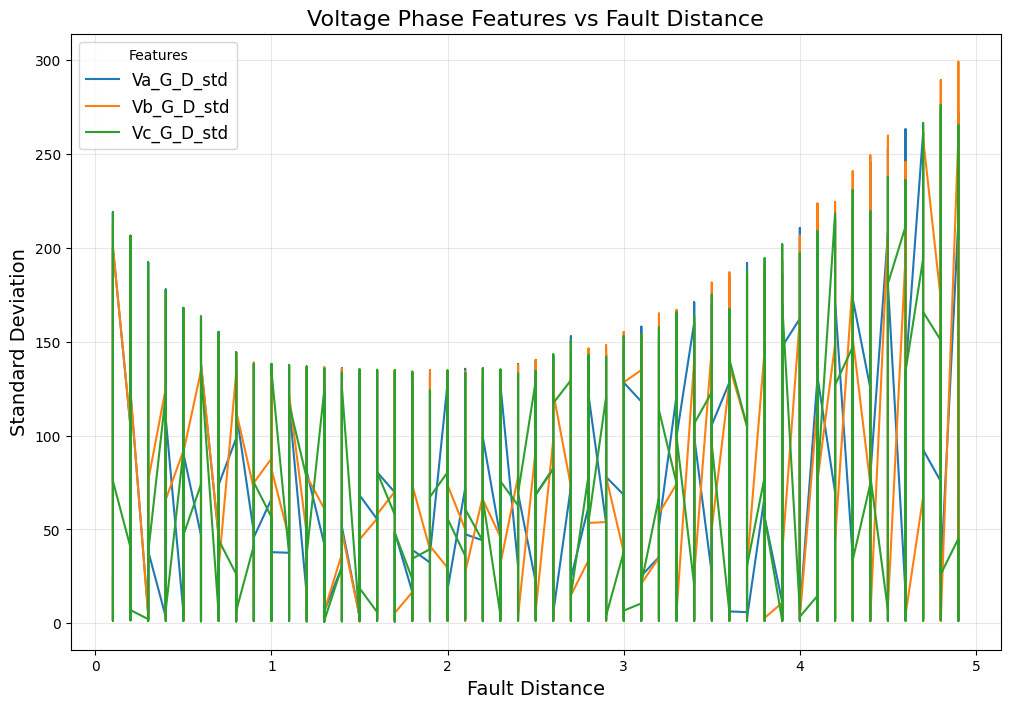

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

columns_to_plot = ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std', 'distance']
df_subset = df[columns_to_plot].sort_values(by='distance')

plt.figure(figsize=(12, 8))

for col in ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std']:
    plt.plot(df_subset['distance'], df_subset[col], label=col)

plt.title('Voltage Phase Features vs Fault Distance', fontsize=16)
plt.xlabel('Fault Distance', fontsize=14)
plt.ylabel('Standard Deviation', fontsize=14)
plt.legend(title='Features', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


(980, 92)


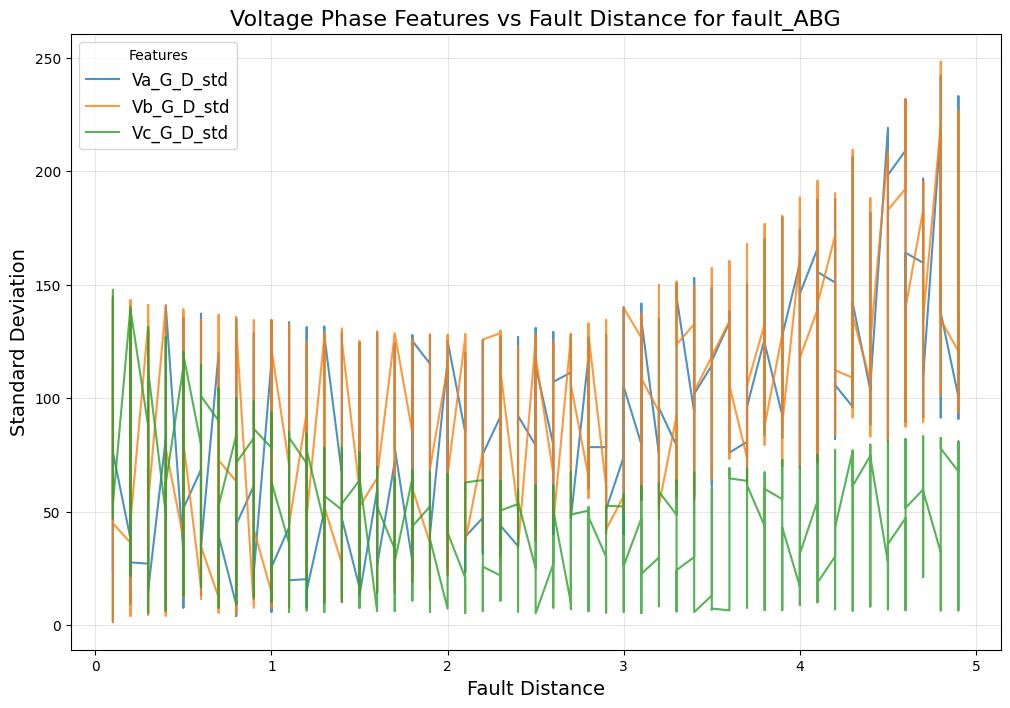

In [ ]:
# Filtering the DataFrame for rows where fault_type is 'fault_ABG' so that we can visualize how location depends on attributes
fault_abg_df = df[df['fault_type'] == 'fault_ABG']
# print(fault_abg_df.shape)

columns_to_plot = ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std', 'distance']
fault_abg_subset = fault_abg_df[columns_to_plot].sort_values(by='distance')

plt.figure(figsize=(12, 8))

for col in ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std']:
    plt.plot(fault_abg_subset['distance'], fault_abg_subset[col], label=col, alpha=0.8)

# Adding plot details
plt.title('Voltage Phase Features vs Fault Distance for fault_ABG', fontsize=16)
plt.xlabel('Fault Distance', fontsize=14)
plt.ylabel('Standard Deviation', fontsize=14)
plt.legend(title='Features', fontsize=12)
plt.grid(alpha=0.3)
plt.show()



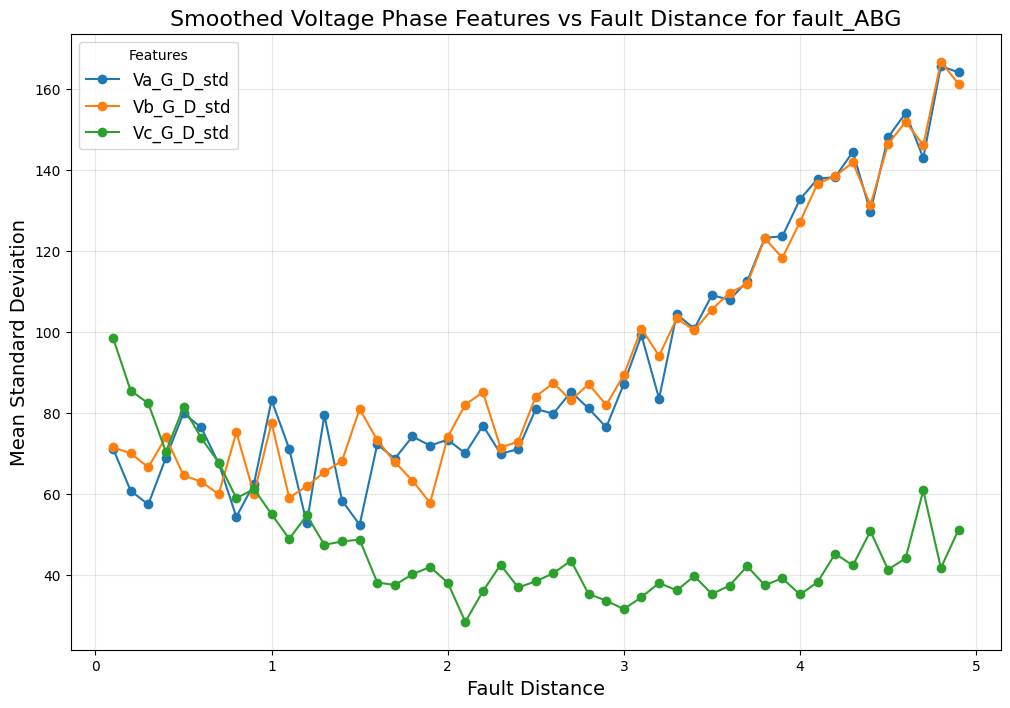

In [ ]:
# Grouping by fault_distance and calculating the mean of each feature
aggregated_fault_abg = fault_abg_subset.groupby('distance').mean().reset_index()

# Plotting each feature against fault_distance
plt.figure(figsize=(12, 8))

for col in ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std']:
    plt.plot(aggregated_fault_abg['distance'], aggregated_fault_abg[col], label=col, marker='o')

# Adding plot details
plt.title('Smoothed Voltage Phase Features vs Fault Distance for fault_ABG', fontsize=16)
plt.xlabel('Fault Distance', fontsize=14)
plt.ylabel('Mean Standard Deviation', fontsize=14)
plt.legend(title='Features', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Group by fault_distance and calculate the mean of each feature
aggregated_fault_abg = fault_abg_subset.groupby('distance').mean().reset_index()

# Plot each feature against fault_distance
plt.figure(figsize=(12, 8))

for col in ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std']:
    plt.plot(aggregated_fault_abg['distance'], aggregated_fault_abg[col], label=col, marker='o')

# Adding plot details
plt.title('Smoothed Voltage Phase Features vs Fault Distance for fault_ABG', fontsize=16)
plt.xlabel('Fault Distance', fontsize=14)
plt.ylabel('Mean Standard Deviation', fontsize=14)
plt.legend(title='Features', fontsize=12)
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Filtering the dataframe for 'fault_ABG' entries
fault_abg_subset = df[df['fault_type'] == 'fault_ABG'].copy()

# Normalizing the standard deviation values for Va_G_D_std, Vb_G_D_std, and Vc_G_D_std
fault_abg_subset[['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std']] = fault_abg_subset[
    ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std']
].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Grouping by fault_distance and calculating the mean of normalized features
normalized_aggregated_fault_abg = fault_abg_subset.groupby('distance').mean().reset_index()

# Plotting the normalized features against fault_distance
plt.figure(figsize=(12, 8))

for col in ['Va_G_D_std', 'Vb_G_D_std', 'Vc_G_D_std']:
    plt.plot(normalized_aggregated_fault_abg['distance'], normalized_aggregated_fault_abg[col], label=col, marker='o')

# Adding plot details
plt.title('Normalized Voltage Phase Features vs Fault Distance for fault_ABG', fontsize=16)
plt.xlabel('Fault Distance', fontsize=14)
plt.ylabel('Normalized Standard Deviation', fontsize=14)
plt.legend(title='Features', fontsize=12)
plt.grid(alpha=0.3)
plt.show()
